In [1]:
import pandas as pd
from collections import Counter
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    confusion_matrix,
    roc_curve, 
    auc,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns
import os

2025-06-17 10:19:42.253225: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-17 10:19:42.256257: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-17 10:19:42.320336: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-17 10:19:42.321533: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-17 10:19:43.284448: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

### Dataset

In [ ]:
df_train = pd.read_csv('../train_set/train_cleaned_outliers.csv')
df_train = df_train.drop('originalTitle', axis=1)
df_train = df_train.drop('averageRating', axis=1)

df_test = pd.read_csv('../test_set/test_no_title.csv')
df_test = df_test.drop('averageRating', axis=1)


### Mappatura etichette

In [3]:
# change all 1, 2, 3 in 4
df_train['rating'] = df_train['rating'].replace([1, 2, 3], 4)
df_test['rating'] = df_test['rating'].replace([1, 2, 3], 4)

# replace all 10 with 9
df_train['rating'] = df_train['rating'].replace(10, 9)
df_test['rating'] = df_test['rating'].replace(10, 9)

In [4]:
import numpy as np
import pandas as pd

# Supponendo che df_train e df_test siano i tuoi DataFrame
label_mapping = {4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5}

df_train['rating'] = df_train['rating'].map(label_mapping)
df_test['rating'] = df_test['rating'].map(label_mapping)

# Verifica che tutte le etichette siano state mappate correttamente
assert df_train['rating'].isnull().sum() == 0, "Alcune etichette di training non sono state mappate correttamente."
assert df_test['rating'].isnull().sum() == 0, "Alcune etichette di test non sono state mappate correttamente."


### Train, validation e test set

In [5]:
X = df_train.drop(columns=['rating'])
y = df_train['rating']


In [9]:
X_test = df_test.drop(columns=['rating', 'genreShort'])
y_test = df_test['rating']


In [7]:
from sklearn.model_selection import train_test_split

# Suddivisione con stratificazione
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,  # 20% per la validazione
    stratify=y,     # Mantiene la distribuzione delle classi
    random_state=42 # Per riproducibilità
)


In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


### Upload modello NN

In [12]:
 # useremo os per costruire il percorso in modo robusto

# Definisci il percorso della cartella in cui si trova il tuo modello
# Questa è la cartella 'Downloads' nel tuo utente specifico
directory_path = '../03_Classification/models/NN_rating_classifier/'

# Definisci il nome del file del tuo modello
model_filename = 'NN_rating_classifier.h5'

# Combina il percorso della directory con il nome del file
# os.path.join() è il modo migliore per farlo, perché gestisce automaticamente
# i separatori di percorso (es. '/' su macOS/Linux, '\' su Windows)
full_model_path = os.path.join(directory_path, model_filename)

print(f"Tentativo di caricare il modello da: {full_model_path}")

# Carica il modello
try:
    loaded_model = keras.models.load_model(full_model_path)
    print("Modello caricato con successo!")

    # Ora puoi interagire con il tuo modello, ad esempio:
    # loaded_model.summary() # Per vedere la struttura del modello
    # predictions = loaded_model.predict(nuovi_dati) # Per fare previsioni

except FileNotFoundError:
    print(f"Errore: Il file '{model_filename}' non è stato trovato nel percorso specificato.")
    print(f"Assicurati che il file esista esattamente qui: {full_model_path}")
except Exception as e:
    print(f"Si è verificato un errore durante il caricamento del modello: {e}")

Tentativo di caricare il modello da: ../03_Classification/models/NN_rating_classifier/NN_rating_classifier.h5


2025-06-17 10:22:03.392409: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-17 10:22:03.433851: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Modello caricato con successo!


### Risultati su test set


--- Valutazione del Modello Caricato sul Test Set ---
Generazione delle previsioni sul test set...


1135/1135 [==============================] - 6s 5ms/step
Previsioni convertite in etichette di classe.
Etichette reali (y_test) già in formato etichetta intera.

--- Metriche di Classificazione ---
Accuratezza sul Test Set: 0.4270

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.38      0.12      0.18      1184
           1       0.46      0.12      0.19      2199
           2       0.37      0.28      0.31      5090
           3       0.39      0.38      0.38      9375
           4       0.47      0.67      0.55     11892
           5       0.41      0.34      0.37      6555

    accuracy                           0.43     36295
   macro avg       0.41      0.32      0.33     36295
weighted avg       0.42      0.43      0.41     36295


F1-macro sul Test Set: 0.3304
F1-weighted sul Test Set: 0.4072

Matrice di Confusione:
[[ 137  123  270  277  216  161]
 [  93  256  740  631  335  144]
 [  59  146 1403 1964 1076  442]
 [  32   29

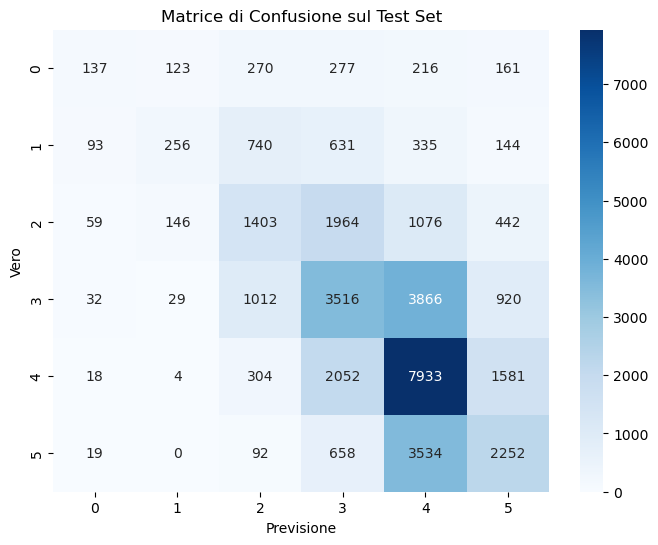


--- Valutazione con .evaluate() di Keras (Test Set) ---
Loss sul Test Set: 1.4328
Accuratezza sul Test Set (da evaluate): 0.4270


In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


print("\n--- Valutazione del Modello Caricato sul Test Set ---")

# 1. Fare previsioni sul test set usando il modello caricato
print("Generazione delle previsioni sul test set...")
y_pred_probs = loaded_model.predict(X_test_scaled)

# 2. Convertire le probabilità in etichette di classe concrete
# Questo è per problemi di classificazione multiclasse (come i rating).
# np.argmax restituisce l'indice della probabilità più alta per ogni campione.
y_pred_classes = np.argmax(y_pred_probs, axis=1)
print("Previsioni convertite in etichette di classe.")

# 3. Valutare le prestazioni
# Se y_test è in formato one-hot encoded, devi convertirlo in etichette intere.
# Dal tuo notebook, sembra che y_test sia già un array di etichette intere, ma è buona pratica ricontrollare.
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_test_labels = np.argmax(y_test, axis=1)
    print("Etichette reali (y_test) convertite da one-hot encoding a etichette intere.")
else:
    y_test_labels = y_test
    print("Etichette reali (y_test) già in formato etichetta intera.")


print("\n--- Metriche di Classificazione ---")

# Accuratezza
accuracy = accuracy_score(y_test_labels, y_pred_classes)
print(f"Accuratezza sul Test Set: {accuracy:.4f}")

# Report di Classificazione dettagliato (Precision, Recall, F1-Score per ogni classe)
print("\nReport di Classificazione:")
# Se conosci i nomi delle tue classi, puoi aggiungerli qui:
# target_names = ['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5']
# print(classification_report(y_test_labels, y_pred_classes, target_names=target_names))
print(classification_report(y_test_labels, y_pred_classes))

# F1-score (macro e weighted)
f1_macro = f1_score(y_test_labels, y_pred_classes, average='macro')
f1_weighted = f1_score(y_test_labels, y_pred_classes, average='weighted')
print(f"\nF1-macro sul Test Set: {f1_macro:.4f}")
print(f"F1-weighted sul Test Set: {f1_weighted:.4f}")

# Matrice di Confusione
print("\nMatrice di Confusione:")
conf_mat = confusion_matrix(y_test_labels, y_pred_classes)
print(conf_mat)

# Visualizzazione della Matrice di Confusione
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test_labels), yticklabels=np.unique(y_test_labels))
plt.xlabel('Previsione')
plt.ylabel('Vero')
plt.title('Matrice di Confusione sul Test Set')
plt.show()

# --- Valutazione con la funzione .evaluate() di Keras ---
# Questa è utile per ottenere la loss e le metriche compilate sul modello.
# Assicurati che y_test sia nel formato corretto per l'evaluate (one-hot se hai usato categorical_crossentropy, intero se sparse_categorical_crossentropy).
print("\n--- Valutazione con .evaluate() di Keras (Test Set) ---")
try:
    # Se y_test è one-hot encoded, usa y_test direttamente
    # Altrimenti, se y_test è un array di interi (come sembra dal tuo notebook), usa y_test_labels
    if y_test.ndim > 1 and y_test.shape[1] > 1: # Se y_test è one-hot
        results = loaded_model.evaluate(X_test_scaled, y_test, verbose=0)
    else: # Se y_test è etichetta intera (come sembra dal tuo notebook)
        results = loaded_model.evaluate(X_test_scaled, y_test_labels, verbose=0)

    print(f"Loss sul Test Set: {results[0]:.4f}")
    if len(results) > 1:
        # Assumendo che la seconda metrica compilata sia l'accuratezza
        print(f"Accuratezza sul Test Set (da evaluate): {results[1]:.4f}")
except Exception as e:
    print(f"Errore durante l'esecuzione di .evaluate(): {e}")
    print("Controlla che X_test_scaled e y_test siano nel formato corretto per .evaluate().")

### LORE

In [16]:
# !pip install deap
# !pip install bitarray


In [17]:
import sys
sys.path.append('./lore')

from lore.lorem import LOREM

In [18]:
from lore.lorem import LOREM

K = X_test_scaled  # oppure anche solo una parte, es. X_test_scaled[:100]

feature_names = X.columns.tolist()
class_name = 'rating'
class_values = sorted(df_train['rating'].unique())  # [0, 1, 2, 3, 4, 5]
numeric_columns = feature_names
features_map = {}  # perché non hai variabili categoriche

# Funzioni predizione
bb_predict = lambda x: np.argmax(loaded_model.predict(x), axis=1)
bb_predict_proba = lambda x: loaded_model.predict(x)

# Costruzione explainer LOREM
lore_explainer = LOREM(
    K, bb_predict, feature_names, class_name, class_values, numeric_columns, features_map,
    neigh_type='geneticp',
    categorical_use_prob=True,
    continuous_fun_estimation=False,
    size=1000,
    ocr=0.1,
    random_state=42,
    ngen=10,
    bb_predict_proba=bb_predict_proba,
    verbose=True
)


calculating feature values


In [20]:
x = X_test_scaled[0]  # oppure: x = X_test_scaled[0].reshape(1, -1)


In [21]:
from lore.util import neuclidean

exp = lore_explainer.explain_instance(x, samples=300, use_weights=True, metric=neuclidean)

generating neighborhood - geneticp
1/1 [==============================] - 0s 51ms/step


1/1 [==============================] - 0s 33ms/step
gen	nevals	avg     	min     	max     
0  	150   	0.496654	0.496654	0.496654
1/1 [==============================] - 0s 49ms/step
1  	132   	0.73128 	0.410056	0.992931
1/1 [==============================] - 0s 56ms/step
2  	132   	0.906939	0.38346 	0.993077
1/1 [==============================] - 0s 40ms/step
3  	125   	0.955698	0.435411	0.99322 
1/1 [==============================] - 0s 59ms/step
4  	125   	0.963708	0.477254	0.993242
1/1 [==============================] - 0s 32ms/step
5  	129   	0.960354	0.310054	0.993242
1/1 [==============================] - 0s 58ms/step
6  	129   	0.959802	0.412389	0.993242
1/1 [==============================] - 0s 87ms/step
7  	127   	0.957738	0.406419	0.993243
1/1 [==============================] - 0s 32ms/step
8  	133   	0.968739	0.412361	0.993243
1/1 [==============================] - 0s 62ms/step
9  	134   	0.949915	0.401103	0.993243
1/1 [==============================] - 0s 30ms/step
10 	126   

In [22]:
print(exp)

r = { totalMedia > -1.11, titleType <= 0.15, castNumber <= 0.03, genreSci-Fi <= 0.50, genreHorror <= 0.17, genreFantasy > -0.12, genreHistory <= 0.50, genreHistory > -0.09, genreWar <= 0.50, genreMystery <= 0.16, genreCrime <= 0.50, genreMusical <= 0.05 } --> { rating: 3 }
c = { { castNumber > 0.10 },
      { genreHorror > 0.17 },
      { totalMedia <= -1.11 } }


In [23]:
# r = {
  #totalMedia <= 0.20,
  #totalMedia > -0.41,
  #companiesNumber > 0.09,
  #titleType <= 0.16,
  #criticReviewsTotal <= 0.02,
  #castNumber <= 0.19,
  #genreMusical > -0.01,
  #genreCrime <= 0.50,
  #runtimeHours <= 0.23,
  #genreNews > -0.06
## --> { rating: 3 }

#Questa è la regola locale trovata da LOREM per spiegare perché il classificatore ha predetto rating: 3 (ricorda: tu hai rimappato rating, quindi questo potrebbe corrispondere al valore originale 7, ad esempio).

#Interpretazione:

#"Se un titolo ha queste caratteristiche (feature x <= y, x > y, ecc.), allora è classificato con rating 3."

In [24]:
from lore.util import record2str


In [27]:
# Valori normalizzati che soddisfano le condizioni della regola
x1 = x.copy()

x1[feature_names.index('totalMedia')] = 0.18          # <= 0.20 and > -0.41
x1[feature_names.index('companiesNumber')] = 0.10     # > 0.09
x1[feature_names.index('titleType')] = 0.10           # <= 0.16
x1[feature_names.index('criticReviewsTotal')] = 0.01  # <= 0.02
x1[feature_names.index('castNumber')] = 0.18          # <= 0.19
x1[feature_names.index('genreMusical')] = 0.00        # > -0.01
x1[feature_names.index('genreCrime')] = 0.40          # <= 0.50
x1[feature_names.index('runtimeHours')] = 0.20        # <= 0.23
x1[feature_names.index('genreNews')] = 0.00           # > -0.06

print('x1 = %s' % record2str(x1, feature_names, numeric_columns))


x1 = { numVotes = 0.0018951358180669614, totalCredits = 0.05263157894736842, criticReviewsTotal = 0.01, titleType = 0.1, userReviewsTotal = 0.0, castNumber = 0.18, companiesNumber = 0.1, writerCredits = 0.08333333333333333, directorsCredits = 0.09090909090909091, quotesTotal = 0.0, startYearDecade = 0.9333333333333336, totalMedia = 0.18, totalRecognitions = 0.0, runtimeHours = 0.2, genreFamily = 0.0, genreDocumentary = 0.0, genreNews = 0.0, genreFilm-Noir = 0.0, genreWestern = 0.0, genreFantasy = 0.0, genreAdult = 0.0, genreAction = 0.0, genreMusic = 0.0, genreComedy = 0.0, genreSport = 0.0, genreHorror = 0.0, genreBiography = 0.0, genreTalk-Show = 0.0, genreDrama = 0.0, genreRomance = 0.0, genreWar = 0.0, genreMystery = 0.0, genreHistory = 0.0, genreSci-Fi = 0.0, genreAnimation = 0.0, genreAdventure = 0.0, genreReality-TV = 0.0, genreMusical = 0.0, genreThriller = 0.0, genreGame-Show = 0.0, genreCrime = 0.4 }


In [28]:
# Reshape per predizione
x1_scaled = x1.reshape(1, -1)

# Predizione del tuo modello
predizione = bb_predict(x1_scaled)[0]
predizione_str = class_values[predizione]  # class_values dovrebbe essere la mappatura inversa come [4, 5, 6, 7, 8, 9]

print(f"bb(x1) = {{ rating: {predizione_str} }}")


1/1 [==============================] - 0s 212ms/step
bb(x1) = { rating: 3 }


In [29]:
pred = loaded_model.predict(x1.reshape(1, -1))
print("Predizione del modello:", pred)


1/1 [==============================] - 0s 199ms/step
Predizione del modello: [[0.06065768 0.08675904 0.19869108 0.24449028 0.21499485 0.19440715]]


In [30]:
# Copia dell'istanza originale
x_cf1 = x.copy()
x_cf1[feature_names.index('castNumber')] = 0.20  # cambia leggermente sopra soglia

x_cf2 = x.copy()
x_cf2[feature_names.index('totalMedia')] = -0.87  # cambia leggermente sotto soglia

# Applichi lo stesso scaler
x_cf1_scaled = scaler.transform(x_cf1.reshape(1, -1))
x_cf2_scaled = scaler.transform(x_cf2.reshape(1, -1))

# Predizioni con modello
outcome1 = bb_predict(x_cf1_scaled)[0]
outcome2 = bb_predict(x_cf2_scaled)[0]

print(f"Predizione cambiando 'castNumber': {class_values[outcome1]}")
print(f"Predizione cambiando 'totalMedia': {class_values[outcome2]}")


1/1 [==============================] - 0s 60ms/step


1/1 [==============================] - 0s 45ms/step
Predizione cambiando 'castNumber': 1
Predizione cambiando 'totalMedia': 1


In [31]:
import numpy as np

# Definizione della funzione bb_predict per usare il tuo modello
def bb_predict(X):
    return np.argmax(loaded_model.predict(X), axis=1)

# Se hai anche bisogno delle probabilità per LOREM
def bb_predict_proba(X):
    return loaded_model.predict(X)

# Prepara l'istanza x1 (modificata)
x1 = x.copy()
x1[feature_names.index('totalMedia')] = 18  # Sostituisci con il nome del tuo feature se diverso

# Normalizza l'istanza con lo stesso scaler usato nel training
x1_scaled = scaler.transform(x1.reshape(1, -1))

# Fai la predizione con il tuo modello
bb_outcome = bb_predict(x1_scaled)[0]
bb_outcome_str = class_values[bb_outcome]

print('bb(x1) = { %s }' % bb_outcome_str)


1/1 [==============================] - 0s 50ms/step
bb(x1) = { 1 }


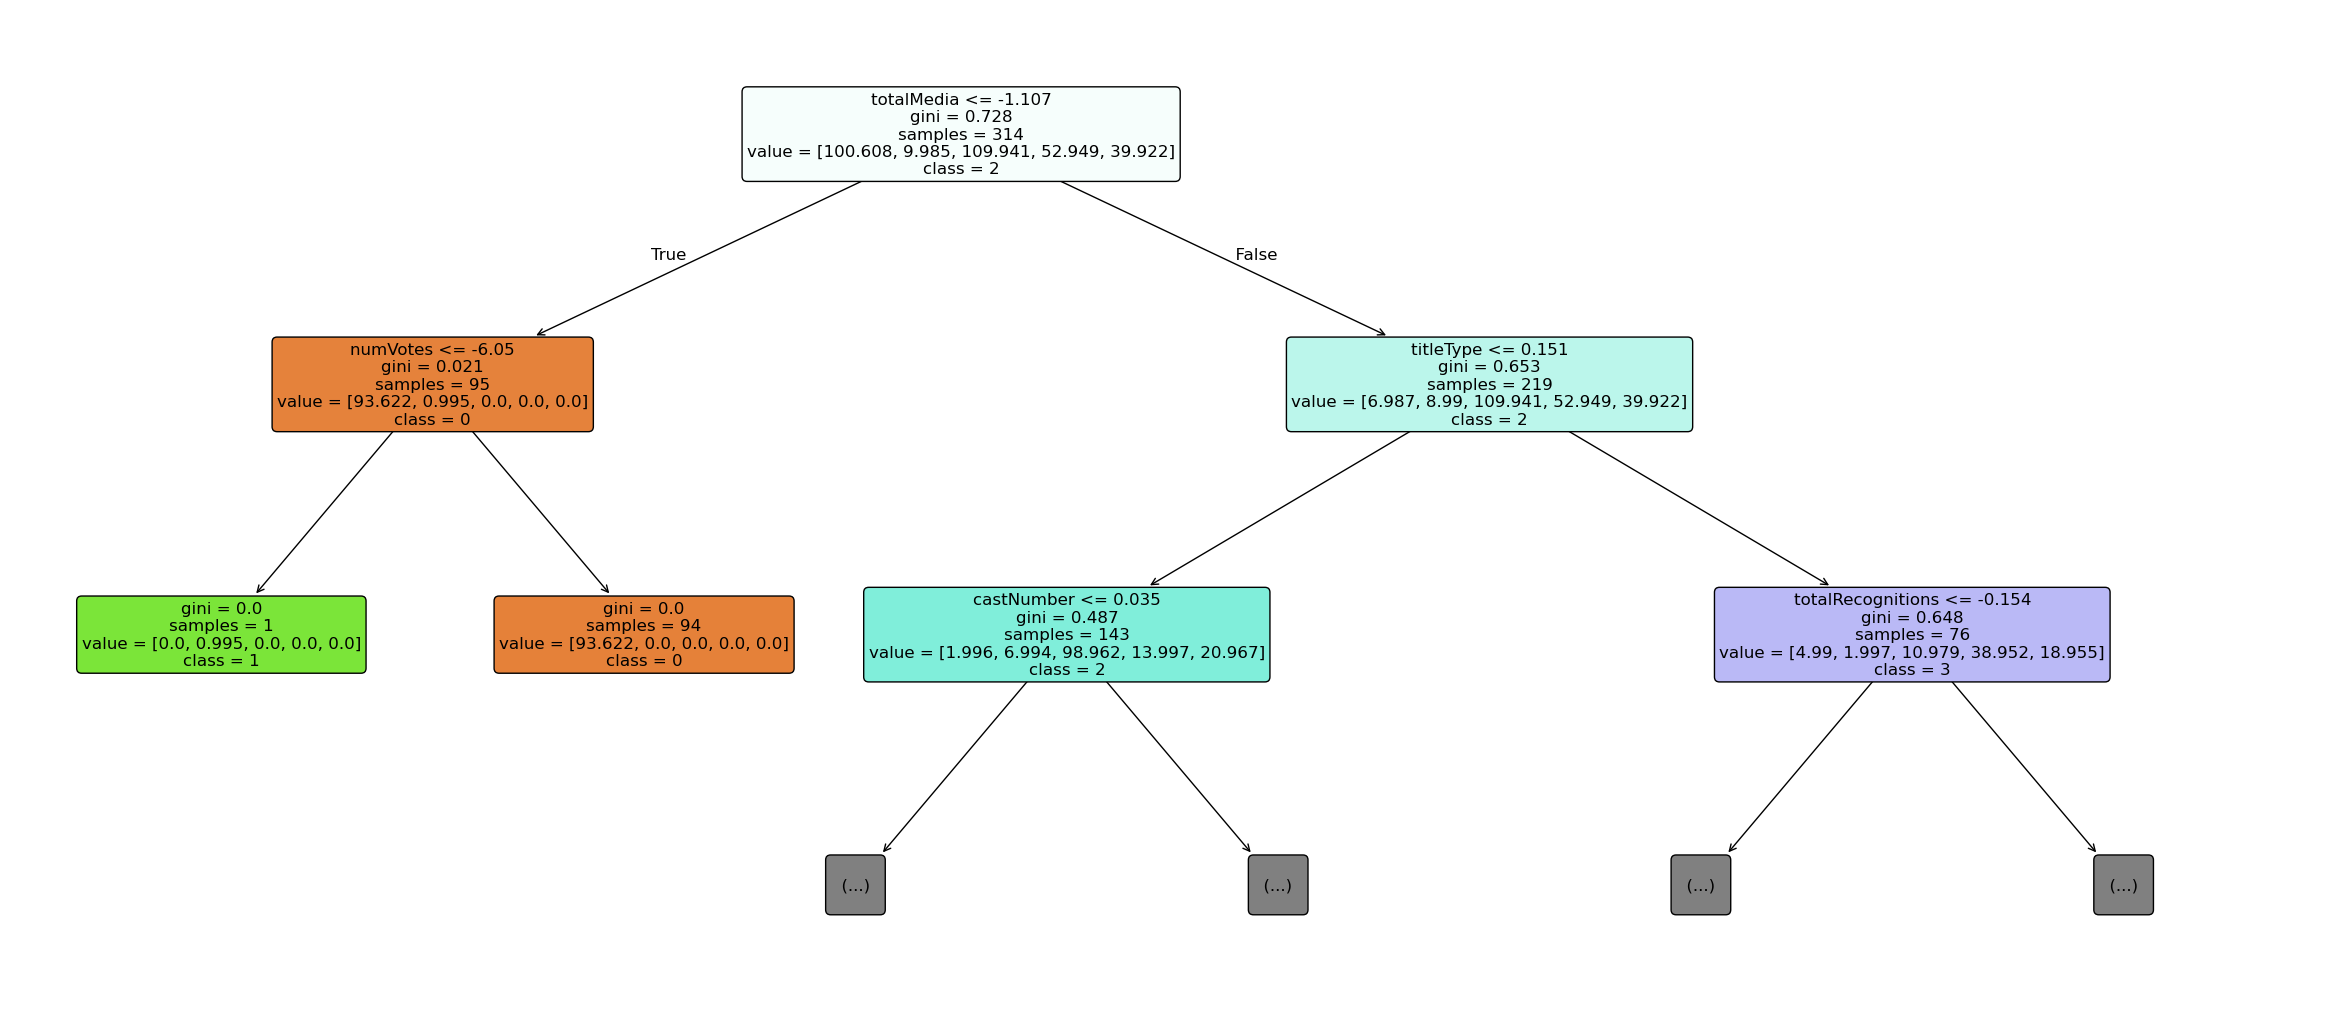

In [32]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 13))
plot_tree(exp.dt, 
          feature_names=feature_names, 
          class_names=[str(val) for val in class_values],  # da 4 a 9
          filled=True, 
          rounded=True,
          fontsize=12,
          max_depth=2)  
plt.show()
